# Ridge Regression Regularization Analysis

This notebook demonstrates the effect of L2 regularization (Ridge regression) on model coefficients and prediction error using an ill-conditioned matrix:
1. Creating a Hilbert matrix (known to be numerically unstable)
2. Implementing ridge regression with varying regularization strengths
3. Visualizing how coefficients and error change with regularization
4. Showing the bias-variance tradeoff controlled by the lambda parameter

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

## Create Ill-Conditioned Problem

The Hilbert matrix $H_{ij} = 1/(i+j-1)$ is the canonical example of a badly conditioned system — small perturbations in the data cause huge changes in the least-squares solution.

In [2]:
# Hilbert matrix: X[i,j] = 1 / (i + j - 1)
X = 1.0 / (np.arange(1, 11) + np.arange(0, 10)[:, np.newaxis])
y = np.ones(10)  # target vector of all ones

## Define Ridge Loss and Sweep Lambda

Ridge regression minimizes $\|Xw - y\|^2 + \lambda\|w\|^2$. We sweep $\lambda$ logarithmically and record the optimal weights and prediction error at each value.

In [3]:
n_lambdas = 200
lambdas = np.logspace(-10, -2, n_lambdas)  # from 10^-10 to 10^-2

coefs = []
mse = []

def loss(w, X, y, alpha):
    return np.sum((X @ w - y) ** 2) + alpha * np.sum(w ** 2)

for l in lambdas:
    res = minimize(loss, np.zeros(10), args=(X, y, l), tol=1e-7)
    coefs.append(res.x)
    mse.append(np.mean((X @ res.x - y) ** 2))

## Visualize Coefficients and Error

As $\lambda$ grows, coefficients shrink toward zero (more bias) but the solution becomes more stable. The bottom plot shows how prediction error changes with regularization strength.

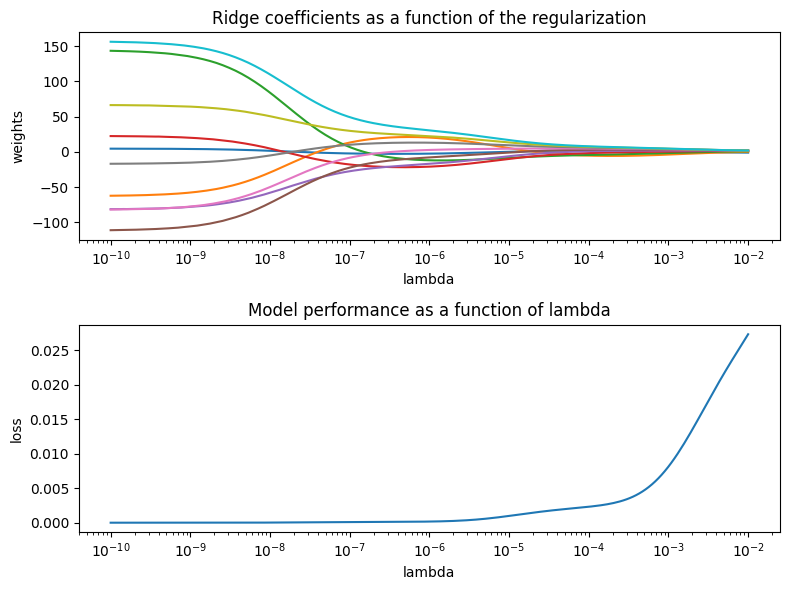

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].plot(lambdas, coefs)
ax[0].set_xscale('log')
ax[0].set_xlabel('lambda')
ax[0].set_ylabel('weights')
ax[0].set_title('Ridge coefficients as a function of the regularization')

ax[1].plot(lambdas, mse)
ax[1].set_xscale('log')
ax[1].set_xlabel('lambda')
ax[1].set_ylabel('loss')
ax[1].set_title('Model performance as a function of lambda')

plt.tight_layout()
plt.show()